### Selección del umbral con Gradiente y Laplaciano

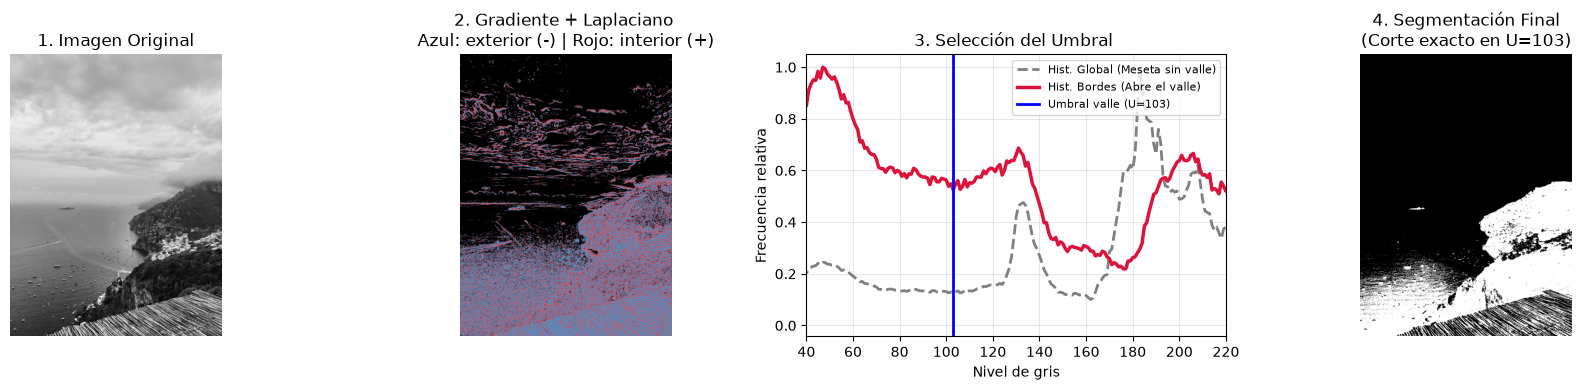

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# CARGA DE IMAGEN
# -------------------------------------------------------------------------
# Cargamos una imagen de ejemplo en escala de grises.
imagen_original = cv2.imread('Positano.jpg', cv2.IMREAD_GRAYSCALE)

if imagen_original is None:
    # Si no encuentra el archivo, generamos una imagen de degradado sintética
    print("Imagen no encontrada. Generando una imagen de degradado para pruebas...")
    imagen_original = np.tile(np.arange(256, dtype=np.uint8), (256, 1))


# Detectar dimensiones de la imagen original
h, w = imagen_original.shape
mapa_visual = np.zeros((h, w, 3), dtype=np.uint8)

# 1. GRADIENTE Y LAPLACIANO 

img_suave = cv2.GaussianBlur(imagen_original, (3, 3), 0)

# Gradiente espacial (magnitud del salto local)
gx = cv2.Sobel(img_suave, cv2.CV_32F, 1, 0, ksize=3)
gy = cv2.Sobel(img_suave, cv2.CV_32F, 0, 1, ksize=3)
grad = cv2.magnitude(gx, gy)

# Laplaciano: clasifica el lado del contorno (cruce por cero en la frontera)
# El laplaciano responde a cambios rápidos de brillo, por lo que puede ayudar a localizar bordes y distinguir los dos lados de una transición por el signo de sus valores.
lap = cv2.Laplacian(img_suave, cv2.CV_32F, ksize=3)

# Clasificación estricta en el contorno (|grad| >= T):
# Estas líneas crean máscaras que seleccionan bordes fuertes y los dividen según el signo de Laplace:
T_grad = 10.0
borde_mask = grad >= T_grad
lado_oscuro = borde_mask & (lap >= 0)  # Signo '+' (lado interior oscuro)
lado_claro  = borde_mask & (lap < 0)   # Signo '-' (lado exterior claro)


# 2. HISTOGRAMAS COMPARADOS (Normalizados para ver la forma de la curva)
# Ambas líneas calculan histogramas de 256 bins de valores de píxeles en escala de grises y transforman los resultados en matrices unidimensionales.

# The arguments specify: input image, channel 0, no mask (None), 256 bins, and intensity range 0–255.
h_global = cv2.calcHist([imagen_original], [0], None, [256], [0, 256]).flatten()

# Primero, selecciona solo los valores de píxeles donde borde_mask es verdadero y luego cuenta esos valores. Por lo tanto, 
# describe la distribución de intensidad en los bordes detectados, en lugar de en toda la imagen.
h_bordes = cv2.calcHist([imagen_original[borde_mask]], [0], None, [256], [0, 256]).flatten()

# Normalizamos a [0, 1] para que ambas curvas se aprecien con claridad
h_global_norm = h_global / np.max(h_global)
h_bordes_norm = h_bordes / np.max(h_bordes)

# Suavizado de la curva de bordes para detectar el mínimo (valle)
# Estas líneas suavizan el histograma de los bordes y buscan el nivel de gris con menor frecuencia 
# entre 60 y 120:
# reshape(-1, 1) convierte el histograma en una columna para que OpenCV pueda aplicar el filtro.
# GaussianBlur(..., (9, 1), 0) suaviza los valores de cada bin usando una ventana de 9 posiciones
# flatten() vuelve a convertir el resultado en un arreglo unidimensional.
h_bordes_smooth = cv2.GaussianBlur(h_bordes_norm.reshape(-1, 1), (9, 1), 0).flatten()
rango_busqueda = np.arange(60, 120)
# Busca cuál de esos niveles tiene la frecuencia suavizada más baja y asigna ese nivel a umbral_optimo. 
# Así, el umbral queda limitado al rango elegido; 
# si el valle real está fuera de 60–120, este código no lo detectará.
umbral_optimo = rango_busqueda[np.argmin(h_bordes_smooth[rango_busqueda])]

# Segmentación binaria con el umbral hallado
_, bin_resultado = cv2.threshold(imagen_original, umbral_optimo, 255, cv2.THRESH_BINARY_INV)


# 3. VISUALIZACIÓN

fig, axs = plt.subplots(1, 4, figsize=(18, 4))

# Panel 1: Original con solapamiento
axs[0].imshow(imagen_original, cmap='gray')
axs[0].set_title("1. Imagen Original")
axs[0].axis('off')

# Panel 2: Mapa de contorno con Laplaciano
mapa_visual = np.zeros((h, w, 3), dtype=np.uint8)
mapa_visual[lado_claro]  = [0, 180, 255] # Azul: Lado claro exterior (-)
mapa_visual[lado_oscuro] = [255, 60, 60] # Rojo: Lado oscuro interior (+)
axs[1].imshow(mapa_visual)
axs[1].set_title("2. Gradiente + Laplaciano \nAzul: exterior (-) | Rojo: interior (+)")
axs[1].axis('off')

# Panel 3: Comparativa de Histogramas 
axs[2].plot(h_global_norm, color='gray', linestyle='--', lw=2, label='Hist. Global (Meseta sin valle)')
axs[2].plot(h_bordes_smooth, color='crimson', lw=2.5, label='Hist. Bordes (Abre el valle)')
axs[2].axvline(umbral_optimo, color='blue', lw=2, linestyle='-', label=f'Umbral valle (U={umbral_optimo})')
axs[2].set_xlim(40, 220)
axs[2].set_title("3. Selección del Umbral ")
axs[2].set_xlabel("Nivel de gris")
axs[2].set_ylabel("Frecuencia relativa")
axs[2].legend(fontsize=8, loc='upper right')
axs[2].grid(True, alpha=0.3)

# Panel 4: Binarización limpia
axs[3].imshow(bin_resultado, cmap='gray')
axs[3].set_title(f"4. Segmentación Final\n(Corte exacto en U={umbral_optimo})")
axs[3].axis('off')

plt.tight_layout()
plt.show()